In [37]:
from google . colab import files
uploaded = files.upload()

Saving Restaurant_sales.csv to Restaurant_sales (1).csv


PART 1 DATA PREPROCESSING

In [2]:
import pandas as pd
df = pd.read_csv("Restaurant_sales.csv")
print(df)

     Order ID        Date             Product  Price  Quantity Purchase Type  \
0       10452  07-11-2022               Fries   3.49    573.07       Online    
1       10453  07-11-2022           Beverages   2.95    745.76       Online    
2       10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3       10455  08-11-2022             Burgers  12.99    569.67     In-store    
4       10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
..        ...         ...                 ...    ...       ...           ...   
249     10709  28-12-2022       Sides & Other   4.99    200.40   Drive-thru    
250     10710  29-12-2022             Burgers  12.99    754.43   Drive-thru    
251     10711  29-12-2022  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712  29-12-2022               Fries   3.49    630.37   Drive-thru    
253     10713  29-12-2022           Beverages   2.95    677.97   Drive-thru    

    Payment Method             Manager 

In [3]:
df['rating'] = np.random.randint(1, 6, size=len(df))

In [4]:
print(df.columns)


Index(['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type',
       'Payment Method', 'Manager', 'City', 'rating'],
      dtype='object')


In [5]:
print(df.head(10))

   Order ID        Date             Product  Price  Quantity Purchase Type  \
0     10452  07-11-2022               Fries   3.49    573.07       Online    
1     10453  07-11-2022           Beverages   2.95    745.76       Online    
2     10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3     10455  08-11-2022             Burgers  12.99    569.67     In-store    
4     10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
5     10457  08-11-2022               Fries   3.49    573.07     In-store    
6     10459  08-11-2022       Sides & Other   4.99    200.40     In-store    
7     10460  09-11-2022             Burgers  12.99    554.27     In-store    
8     10461  09-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
9     10462  09-11-2022               Fries   3.49    573.07     In-store    

  Payment Method             Manager    City  rating  
0      Gift Card    Tom      Jackson  London       3  
1      Gift Card         Pablo 

In [6]:
print(df.shape)

(254, 10)


In [7]:
print(df.columns)

Index(['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type',
       'Payment Method', 'Manager', 'City', 'rating'],
      dtype='object')


In [8]:
print(df.dtypes)

Order ID            int64
Date               object
Product            object
Price             float64
Quantity          float64
Purchase Type      object
Payment Method     object
Manager            object
City               object
rating              int64
dtype: object


 2. Clean Column Names

In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print(df.columns)

Index(['order_id', 'date', 'product', 'price', 'quantity', 'purchase_type',
       'payment_method', 'manager', 'city', 'rating'],
      dtype='object')


 3. Handle Missing Values

In [10]:
print(df.isnull().sum())


order_id          0
date              0
product           0
price             0
quantity          0
purchase_type     0
payment_method    0
manager           0
city              0
rating            0
dtype: int64


In [11]:
missing_per = (df.isnull().sum() / len(df)) * 100
print(missing_per)

order_id          0.0
date              0.0
product           0.0
price             0.0
quantity          0.0
purchase_type     0.0
payment_method    0.0
manager           0.0
city              0.0
rating            0.0
dtype: float64


In [13]:
print(df.columns.tolist())

['order_id', 'date', 'product', 'price', 'quantity', 'purchase_type', 'payment_method', 'manager', 'city', 'rating']


•	Fill:
o	Missing rating → median
o	Missing payment_method → mode


In [14]:
df['rating'] = df['rating'].fillna(df['rating'].median())
print(df)

     order_id        date             product  price  quantity purchase_type  \
0       10452  07-11-2022               Fries   3.49    573.07       Online    
1       10453  07-11-2022           Beverages   2.95    745.76       Online    
2       10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3       10455  08-11-2022             Burgers  12.99    569.67     In-store    
4       10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
..        ...         ...                 ...    ...       ...           ...   
249     10709  28-12-2022       Sides & Other   4.99    200.40   Drive-thru    
250     10710  29-12-2022             Burgers  12.99    754.43   Drive-thru    
251     10711  29-12-2022  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712  29-12-2022               Fries   3.49    630.37   Drive-thru    
253     10713  29-12-2022           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager 

In [15]:
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode())
print(df)

     order_id        date             product  price  quantity purchase_type  \
0       10452  07-11-2022               Fries   3.49    573.07       Online    
1       10453  07-11-2022           Beverages   2.95    745.76       Online    
2       10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3       10455  08-11-2022             Burgers  12.99    569.67     In-store    
4       10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
..        ...         ...                 ...    ...       ...           ...   
249     10709  28-12-2022       Sides & Other   4.99    200.40   Drive-thru    
250     10710  29-12-2022             Burgers  12.99    754.43   Drive-thru    
251     10711  29-12-2022  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712  29-12-2022               Fries   3.49    630.37   Drive-thru    
253     10713  29-12-2022           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager 

Remove Duplicates
•	Count duplicate rows
•	Remove duplicates

In [16]:
print("count duplicated",df.duplicated().sum())

count duplicated 0


In [17]:
df.drop_duplicates()
print(df)

     order_id        date             product  price  quantity purchase_type  \
0       10452  07-11-2022               Fries   3.49    573.07       Online    
1       10453  07-11-2022           Beverages   2.95    745.76       Online    
2       10454  07-11-2022       Sides & Other   4.99    200.40     In-store    
3       10455  08-11-2022             Burgers  12.99    569.67     In-store    
4       10456  08-11-2022  Chicken Sandwiches   9.95    201.01     In-store    
..        ...         ...                 ...    ...       ...           ...   
249     10709  28-12-2022       Sides & Other   4.99    200.40   Drive-thru    
250     10710  29-12-2022             Burgers  12.99    754.43   Drive-thru    
251     10711  29-12-2022  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712  29-12-2022               Fries   3.49    630.37   Drive-thru    
253     10713  29-12-2022           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager 

In [18]:
# Convert to integer
df['rating'] = df['rating'].astype(int)
print(df.dtypes)

order_id            int64
date               object
product            object
price             float64
quantity          float64
purchase_type      object
payment_method     object
manager            object
city               object
rating              int64
dtype: object


In [19]:
#order_id = integer
df['product']= df['product'].astype(str)
print(df.dtypes)

order_id            int64
date               object
product            object
price             float64
quantity          float64
purchase_type      object
payment_method     object
manager            object
city               object
rating              int64
dtype: object


In [20]:
#price = float
df['price'] = df['price'].astype(float)
print(df.dtypes)

order_id            int64
date               object
product            object
price             float64
quantity          float64
purchase_type      object
payment_method     object
manager            object
city               object
rating              int64
dtype: object


In [21]:
#quantity = float
df['quantity'] = df['quantity'].astype(float)
print(df.dtypes)

order_id            int64
date               object
product            object
price             float64
quantity          float64
purchase_type      object
payment_method     object
manager            object
city               object
rating              int64
dtype: object


In [22]:
#date = datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
print(df.dtypes)

order_id                   int64
date              datetime64[ns]
product                   object
price                    float64
quantity                 float64
purchase_type             object
payment_method            object
manager                   object
city                      object
rating                     int64
dtype: object


#Visualization

In [23]:
!pip install matplotlib
import matplotlib.pyplot as plt

#Boxplot

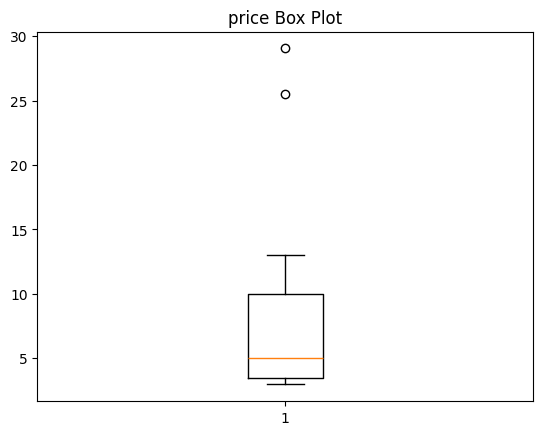

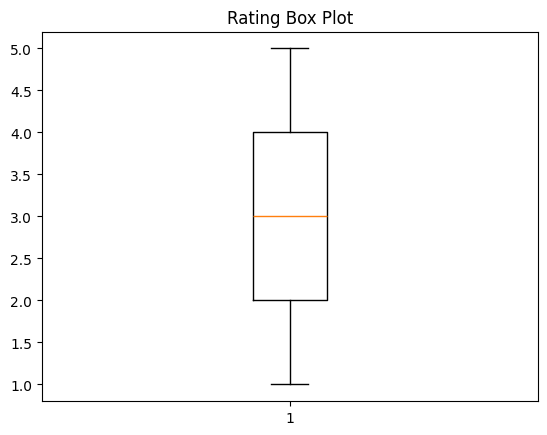

In [24]:
plt.boxplot(df['price'])
plt.title('price Box Plot')
plt.show()

plt.boxplot(df['rating'])
plt.title('Rating Box Plot')
plt.show()

#Bar - Average Rating per Restaurant Type

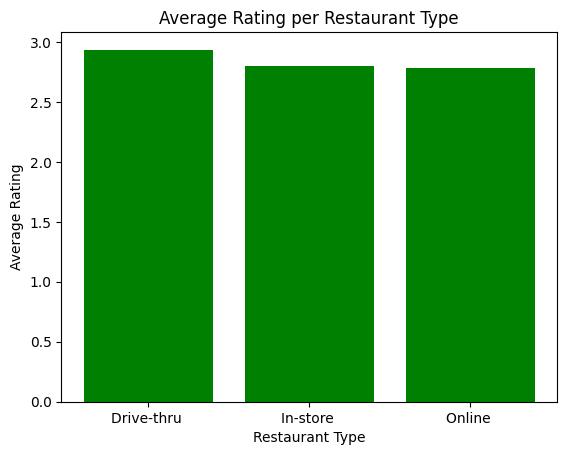

In [25]:
import matplotlib.pyplot as plt

avg_rating = df.groupby('purchase_type')['rating'].mean()

plt.figure()
plt.bar(avg_rating.index, avg_rating.values, color='green')

plt.title('Average Rating per Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')

plt.show()

#Boxplot - Customer Rating Distribution by Restaurant Type

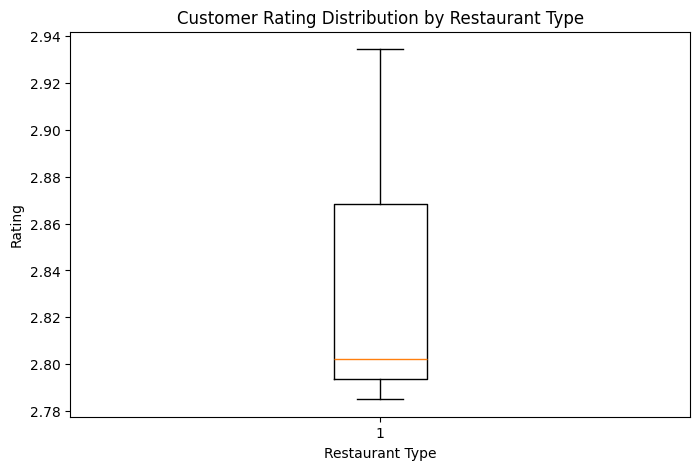

In [26]:
plt.figure(figsize=(8,5))

plt.boxplot(avg_rating)
plt.title('Customer Rating Distribution by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Rating')

plt.show()

#Bar - Average Rating per Restaurant Type

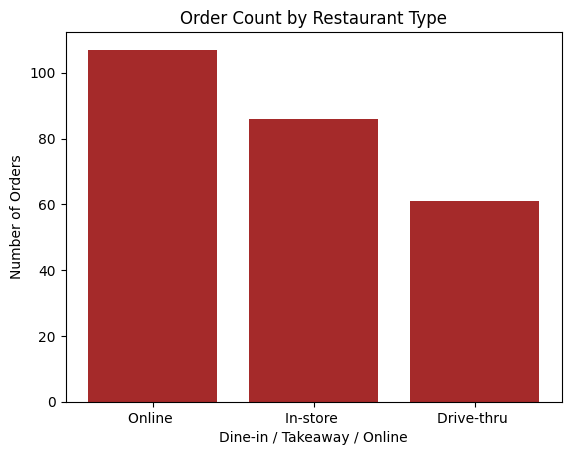

In [27]:

import matplotlib.pyplot as plt
order_counts = df['purchase_type'].value_counts()
plt.bar(order_counts.index, order_counts.values, color='brown')

plt.title('Order Count by Restaurant Type')
plt.xlabel('Dine-in / Takeaway / Online')
plt.ylabel('Number of Orders')

plt.show()

#Revenue by Restaurant Type
•	Total revenue comparison
•	Bar chart


In [28]:
df['revenue'] = df['price'] * df['quantity']
revenue_by_type = df.groupby('purchase_type')['revenue'].sum()
print(revenue_by_type)

purchase_type
Drive-thru     178600.4730
In-store       285713.9994
Online         305201.3868
Name: revenue, dtype: float64


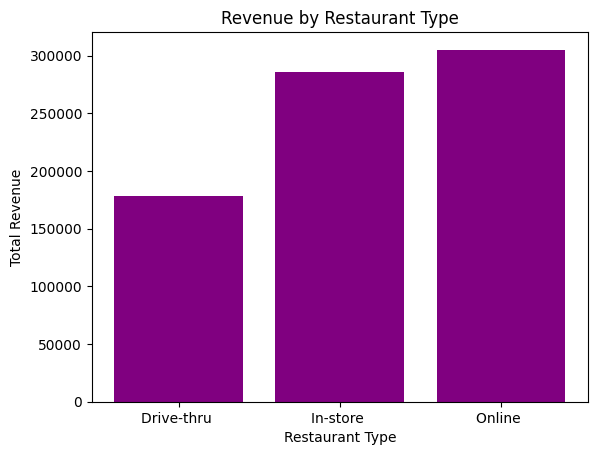

In [29]:
revenue_by_type = df.groupby('purchase_type')['revenue'].sum()

plt.bar(revenue_by_type.index, revenue_by_type.values, color='purple')

plt.title('Revenue by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Revenue')

plt.show()

# Orders by Time Slot • Morning / Afternoon / Evening / Night • Bar chart with colors

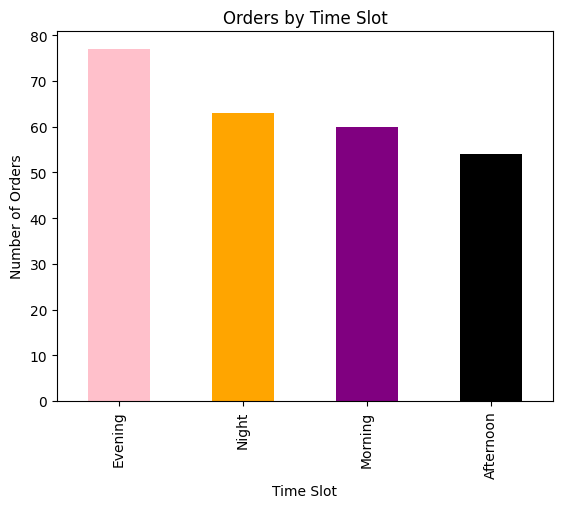

In [30]:
df['time_slot'] = np.random.choice(
    ['Morning', 'Afternoon', 'Evening', 'Night'],
    size=len(df)
)

df['time_slot'].value_counts().plot(
    kind='bar',
    color=['pink','orange','purple','black']
)

plt.title('Orders by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Orders')

plt.show()

#Payment Method Analysis
•	Cash / UPI / Card
•	Pie chart or bar plot

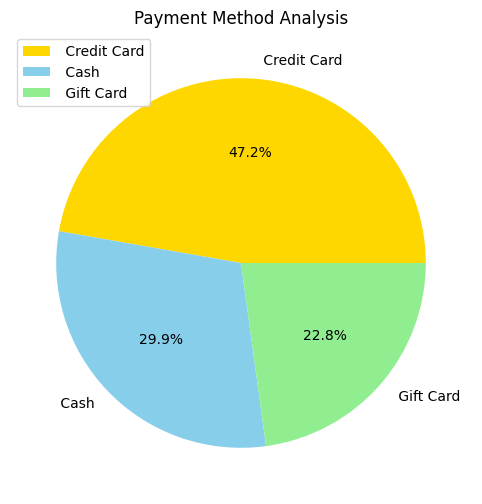

In [31]:
import matplotlib.pyplot as plt

payment_counts = df['payment_method'].value_counts()
plt.figure(figsize=(8,6))
colors = ['gold','skyblue','lightgreen']
plt.pie(payment_counts, labels=payment_counts.index, colors=colors, autopct='%1.1f%%')
plt.title("Payment Method Analysis")
plt.legend()
plt.show()

#Food Category Analysis
•	Category (Chinese, Indian, Fast Food, etc.)
•	Count of orders
•	Total revenue per category

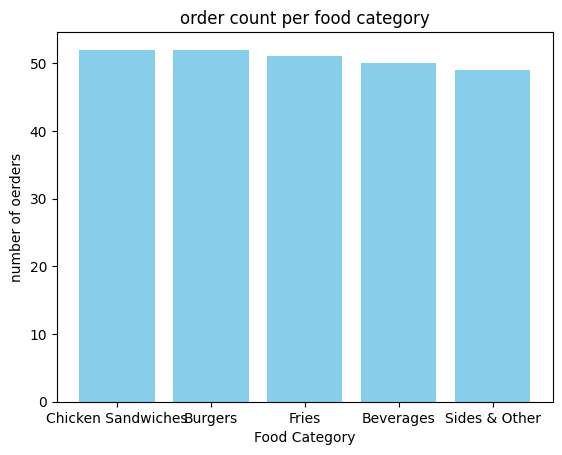

In [32]:
category_counts = df['product'].value_counts()

plt.figure()
plt.bar(category_counts.index, category_counts.values, color = 'skyblue')

plt.title('order count per food category')
plt.xlabel("Food Category")
plt.ylabel("number of oerders")
plt.show()

•	Total revenue per category

In [33]:
category_revenue = df.groupby('product')['revenue'].sum()
print(category_revenue)

product
Beverages             103200.2630
Burgers               376999.8069
Chicken Sandwiches    114641.6950
Fries                 125674.2903
Sides & Other          48999.8040
Name: revenue, dtype: float64


In [34]:
category_counts = df['product'].value_counts()
print(category_counts)

product
Chicken Sandwiches    52
Burgers               52
Fries                 51
Beverages             50
Sides & Other         49
Name: count, dtype: int64


In [39]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

df = remove_outliers_iqr(df, 'rating')
print(df)

     order_id       date             product  price  quantity purchase_type  \
0       10452 2022-11-07               Fries   3.49    573.07       Online    
1       10453 2022-11-07           Beverages   2.95    745.76       Online    
2       10454 2022-11-07       Sides & Other   4.99    200.40     In-store    
3       10455 2022-11-08             Burgers  12.99    569.67     In-store    
4       10456 2022-11-08  Chicken Sandwiches   9.95    201.01     In-store    
..        ...        ...                 ...    ...       ...           ...   
249     10709 2022-12-28       Sides & Other   4.99    200.40   Drive-thru    
250     10710 2022-12-29             Burgers  12.99    754.43   Drive-thru    
251     10711 2022-12-29  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712 2022-12-29               Fries   3.49    630.37   Drive-thru    
253     10713 2022-12-29           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager    city  rat

# Feature Engineering (Important 🔥)
Create new columns:
•	month from order_date
•	day_of_week
•	time_slot (Morning / Afternoon / Evening / Night)


In [40]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
print(df)

     order_id       date             product  price  quantity purchase_type  \
0       10452 2022-11-07               Fries   3.49    573.07       Online    
1       10453 2022-11-07           Beverages   2.95    745.76       Online    
2       10454 2022-11-07       Sides & Other   4.99    200.40     In-store    
3       10455 2022-11-08             Burgers  12.99    569.67     In-store    
4       10456 2022-11-08  Chicken Sandwiches   9.95    201.01     In-store    
..        ...        ...                 ...    ...       ...           ...   
249     10709 2022-12-28       Sides & Other   4.99    200.40   Drive-thru    
250     10710 2022-12-29             Burgers  12.99    754.43   Drive-thru    
251     10711 2022-12-29  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712 2022-12-29               Fries   3.49    630.37   Drive-thru    
253     10713 2022-12-29           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager    city  rat

In [41]:
df['month'] = df['date'].dt.month
print(df)

     order_id       date             product  price  quantity purchase_type  \
0       10452 2022-11-07               Fries   3.49    573.07       Online    
1       10453 2022-11-07           Beverages   2.95    745.76       Online    
2       10454 2022-11-07       Sides & Other   4.99    200.40     In-store    
3       10455 2022-11-08             Burgers  12.99    569.67     In-store    
4       10456 2022-11-08  Chicken Sandwiches   9.95    201.01     In-store    
..        ...        ...                 ...    ...       ...           ...   
249     10709 2022-12-28       Sides & Other   4.99    200.40   Drive-thru    
250     10710 2022-12-29             Burgers  12.99    754.43   Drive-thru    
251     10711 2022-12-29  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712 2022-12-29               Fries   3.49    630.37   Drive-thru    
253     10713 2022-12-29           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager    city  rat

In [42]:
df['day_of_week'] = df['date'].dt.day_name()

In [43]:
df['hour'] = df['date'].dt.hour

In [44]:
print(df)

     order_id       date             product  price  quantity purchase_type  \
0       10452 2022-11-07               Fries   3.49    573.07       Online    
1       10453 2022-11-07           Beverages   2.95    745.76       Online    
2       10454 2022-11-07       Sides & Other   4.99    200.40     In-store    
3       10455 2022-11-08             Burgers  12.99    569.67     In-store    
4       10456 2022-11-08  Chicken Sandwiches   9.95    201.01     In-store    
..        ...        ...                 ...    ...       ...           ...   
249     10709 2022-12-28       Sides & Other   4.99    200.40   Drive-thru    
250     10710 2022-12-29             Burgers  12.99    754.43   Drive-thru    
251     10711 2022-12-29  Chicken Sandwiches   9.95    281.41   Drive-thru    
252     10712 2022-12-29               Fries   3.49    630.37   Drive-thru    
253     10713 2022-12-29           Beverages   2.95    677.97   Drive-thru    

    payment_method             manager    city  rat

In [45]:
print(df.columns)

Index(['order_id', 'date', 'product', 'price', 'quantity', 'purchase_type',
       'payment_method', 'manager', 'city', 'rating', 'revenue', 'time_slot',
       'month', 'day_of_week', 'hour'],
      dtype='object')


Customer Rating Analysis
•	Average rating per restaurant
•	Boxplot or bar chart


In [46]:
avg_rating = df.groupby('purchase_type')['rating'].mean()
print(avg_rating)

purchase_type
Drive-thru     2.934426
In-store       2.802326
Online         2.785047
Name: rating, dtype: float64


PART–2: EXPLORATORY DATA ANALYSIS (EDA)
Use Matplotlib


In [47]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['order_id', 'date', 'product', 'price', 'quantity', 'purchase_type',
       'payment_method', 'manager', 'city', 'rating', 'revenue', 'time_slot',
       'month', 'day_of_week', 'hour'],
      dtype='object')


In [48]:
payment_counts = df['payment_method'].value_counts()
print(payment_counts)

payment_method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64


In [49]:
category_counts = df['product'].value_counts()
print(category_counts)

product
Chicken Sandwiches    52
Burgers               52
Fries                 51
Beverages             50
Sides & Other         49
Name: count, dtype: int64


In [50]:
df['revenue'] = df['price'] * df['quantity']
category_revenue = df.groupby('product')['revenue'].sum()
print(category_revenue)

product
Beverages             103200.2630
Burgers               376999.8069
Chicken Sandwiches    114641.6950
Fries                 125674.2903
Sides & Other          48999.8040
Name: revenue, dtype: float64


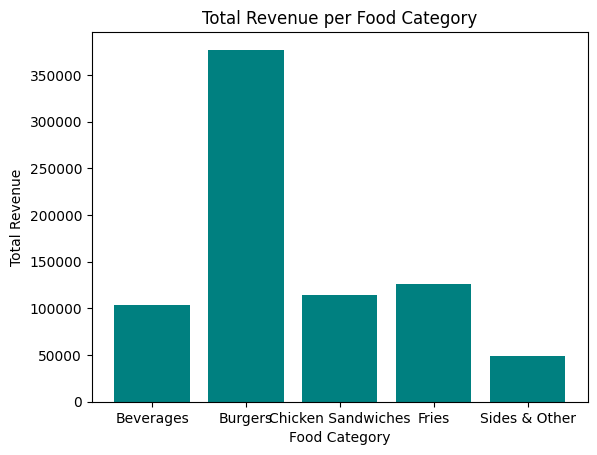

In [51]:

plt.bar(category_revenue.index, category_revenue.values, color='teal')

plt.title('Total Revenue per Food Category')
plt.xlabel('Food Category')
plt.ylabel('Total Revenue')

plt.show()

In [52]:
df['revenue'] = df['price'] * df['quantity']
city_revenue = df.groupby('city')['revenue'].sum()
print(city_revenue)

city
Berlin    100600.1313
Lisbon    241714.1157
London    211201.0406
Madrid    136200.2665
Paris      79800.3051
Name: revenue, dtype: float64


In [53]:
top_cities = city_revenue.head()
print(top_cities)


city
Berlin    100600.1313
Lisbon    241714.1157
London    211201.0406
Madrid    136200.2665
Paris      79800.3051
Name: revenue, dtype: float64


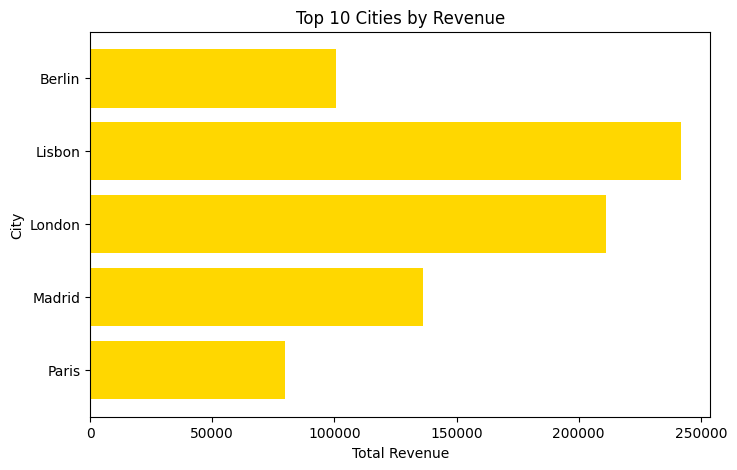

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_cities.index, top_cities.values , color = 'gold')

plt.title('Top 10 Cities by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('City')

plt.gca().invert_yaxis()  # highest revenue on top
plt.show()

Monthly Revenue Trend
•	Line chart
•	Identify peak months


In [55]:
df['revenue'] = df['price'] * df['quantity']
monthly_revenue = df.groupby('month')['revenue'].sum()
print(monthly_revenue)

month
11    332114.6584
12    437401.2008
Name: revenue, dtype: float64


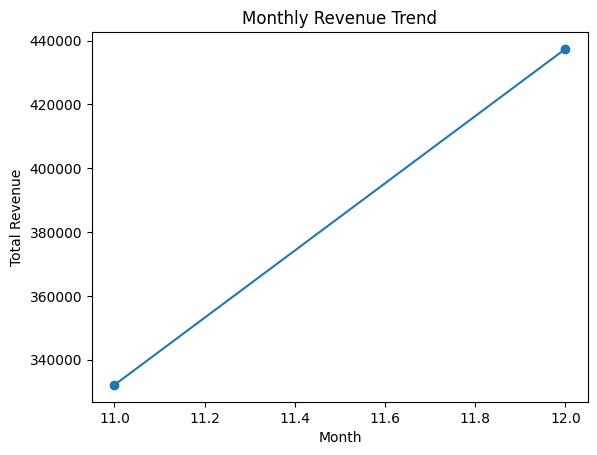

In [56]:
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

In [57]:
print(monthly_revenue)

month
11    332114.6584
12    437401.2008
Name: revenue, dtype: float64


Top 10 Selling Dishes
•	Based on order count
•	Bar chart


In [58]:
top_dishes = df['product'].value_counts().head(10)
print(top_dishes)

product
Chicken Sandwiches    52
Burgers               52
Fries                 51
Beverages             50
Sides & Other         49
Name: count, dtype: int64


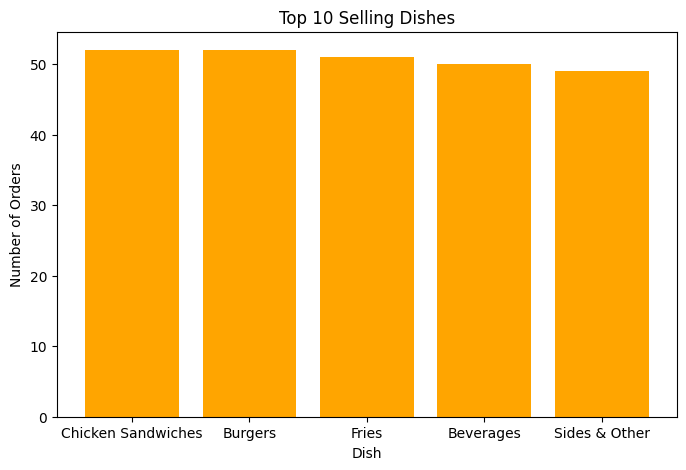

In [59]:
import matplotlib.pyplot as plt

top_dishes = df['product'].value_counts().head(5)

plt.figure(figsize=(8,5))
plt.bar(top_dishes.index, top_dishes.values, color = 'orange')

plt.title('Top 10 Selling Dishes')
plt.xlabel('Dish')
plt.ylabel('Number of Orders')


plt.show()

relatinship analysis
order amount vs rating(scatter plot)
order vs revenue

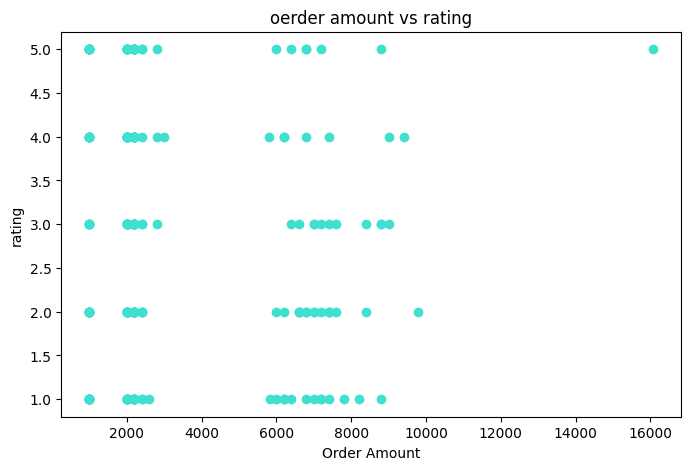

In [60]:
df['order_amount'] = df['price'] * df['quantity']

plt.figure(figsize=(8,5))
plt.scatter(df['order_amount'],df['rating'],color='turquoise')

plt.title("oerder amount vs rating")
plt.xlabel("Order Amount")
plt.ylabel("rating")
plt.show()

In [61]:
#order vs revenue

order_revenue = df.groupby('product').agg({ 'order_id':'count',
                                              'revenue':'sum'})
print(order_revenue)

                    order_id      revenue
product                                  
Beverages                 50  103200.2630
Burgers                   52  376999.8069
Chicken Sandwiches        52  114641.6950
Fries                     51  125674.2903
Sides & Other             49   48999.8040


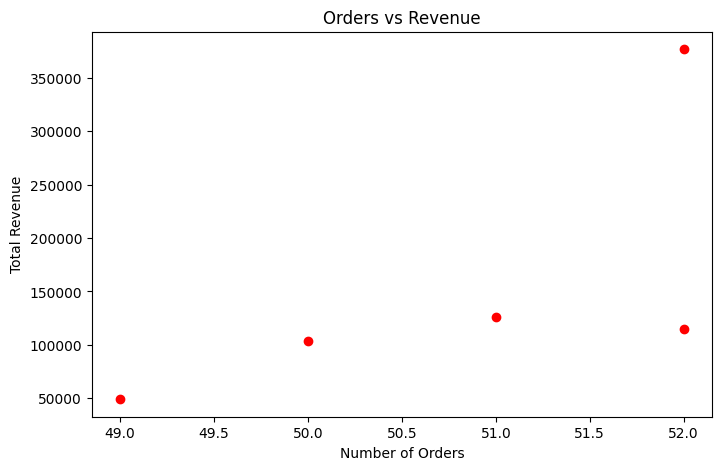

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(order_revenue['order_id'], order_revenue['revenue'],color='red')

plt.title('Orders vs Revenue')
plt.xlabel('Number of Orders')
plt.ylabel('Total Revenue')

plt.show()

Distribution Plots
•	Order amount distribution (Histogram)
•	Rating distribution


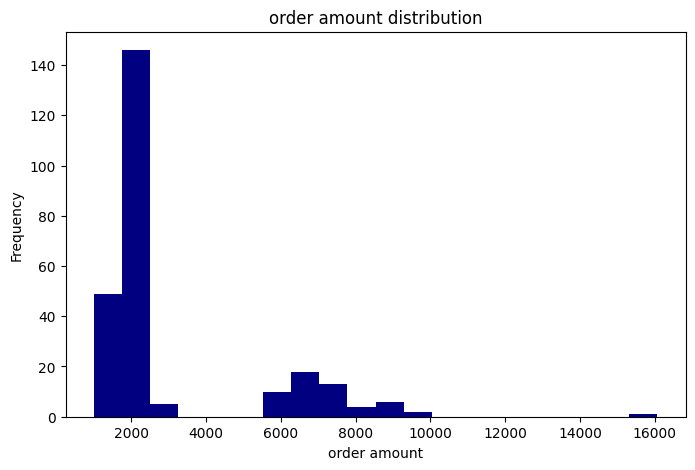

In [63]:
#order amount distribution (histogram)
df['order_amlount'] = df['price'] * df['quantity']

plt.figure(figsize=(8,5))
plt.hist(df['order_amount'],bins=20, color='navy')
plt.title("order amount distribution")
plt.xlabel("order amount")
plt.ylabel("Frequency")
plt.show()

In [64]:
print(df['rating'].unique())

[3 2 4 1 5]


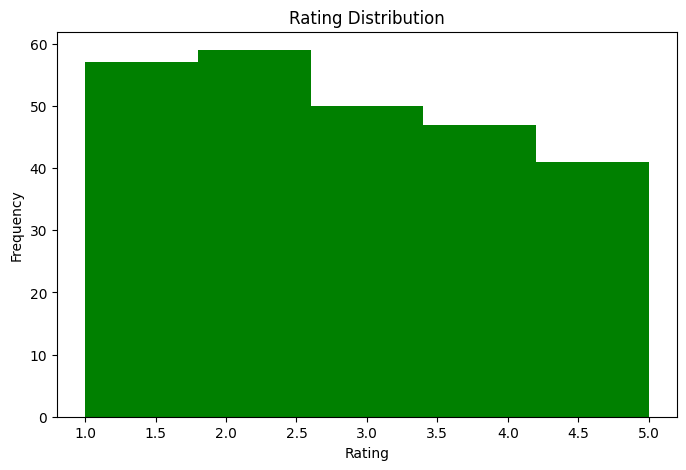

In [65]:
plt.figure(figsize=(8,5))
plt.hist(df['rating'], bins=5, color='green')

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

Correlation Heatmap
Columns:
•	order_amount
•	rating
•	number_of_items


In [66]:
df['order_amount'] = df['price'] * df['quantity']
df['number_of_items'] = df['quantity']

corr = df[['order_amount', 'rating', 'number_of_items']].corr()
print(corr)

                 order_amount    rating  number_of_items
order_amount         1.000000 -0.035696         0.348593
rating              -0.035696  1.000000         0.039042
number_of_items      0.348593  0.039042         1.000000


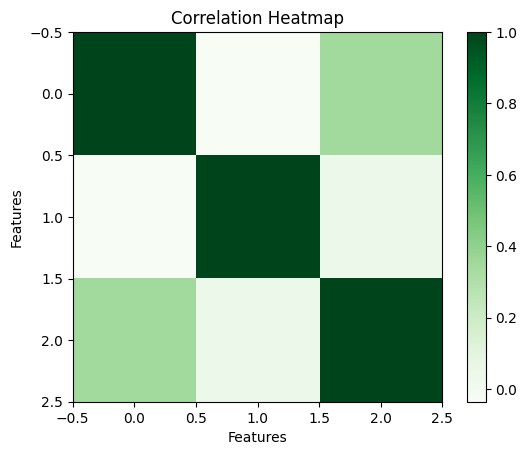

In [67]:


# Create columns
df['order_amount'] = df['price'] * df['quantity']
df['number_of_items'] = df['quantity']

# Correlation data
data1 = df[['order_amount','rating','number_of_items']].corr()

# Heatmap
plt.imshow(data1, cmap='Greens')

# Color bar
plt.colorbar()

# Labels and title
plt.title('Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')

# Show
plt.show()

PART–3: INSIGHTS SUMMARY (Written Task)


Students must answer:
•	Which restaurant type earns more?
=>online

•	Which time slot has maximum orders?
=>morning,Evening

•	Which city generates highest revenue?
=>lisbon

•	Which food category is most popular?
=>Burgers,chicken sandwich

•	Which payment method is preferred?
=>creditcard

•	Which month has highest sales?
=>december

 **Write 10 business insights**

**Business Insights**

1.Fast Food generated the highest number of orders, indicating strong customer demand in this category.

2.Dinner time recorded the maximum orders, making it the busiest period for restaurant sales.

3.Online payment methods were used more frequently than cash payments, showing customers' preference for digital transactions.

4.A few food categories contributed the majority of total revenue, while other categories had comparatively lower sales.

5.Some cities consistently generated higher revenue than others, indicating stronger market demand in those locations.

6.Highly rated restaurants generally received more orders, suggesting that customer ratings influence purchasing decisions.

7.Weekends experienced higher sales compared to weekdays, reflecting increased customer activity during holidays.

8.The average order value varied across restaurant types, helping identify restaurants with higher customer spending.

9.Monthly sales trends revealed seasonal fluctuations, with certain months showing significantly higher revenue.

10.Feature engineering (Order Amount and Time Slot) provided deeper insights into customer purchasing behaviour and sales performance.



